# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [3]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


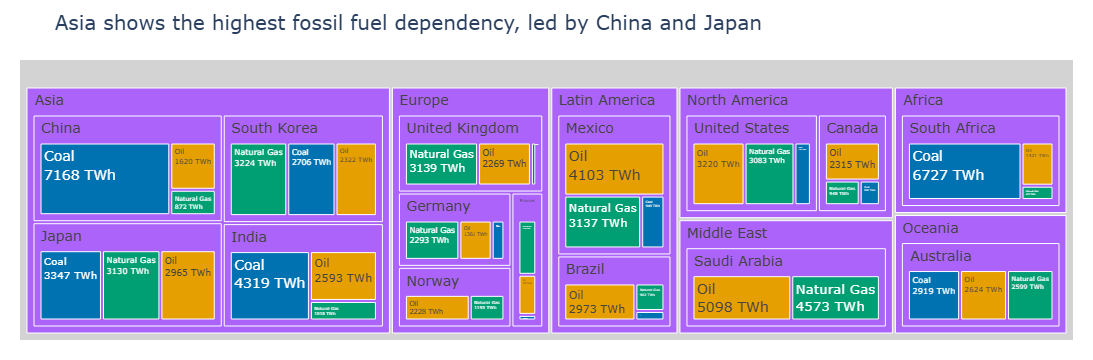

In [5]:
# Task 1
# YOUR CODE HERE
fossil_df = df.loc[df["Source_Type"] == "Fossil"]
fig = px.treemap(
    fossil_df,
    path=["Region", "Country", "Source"],
    values="TWh",
    color="Source",   # colour encodes meaningful fossil category
    color_discrete_map={
        "Coal": "#0072B2",         # blue
        "Oil": "#E69F00",          # orange
        "Natural Gas": "#009E73"   # green
    },
    title="Asia shows the highest fossil fuel dependency, led by China and Japan"
)

# Customise labels: show TWh only, remove percentages
fig.update_traces(
    textinfo="label+value",
    texttemplate="%{label}<br>%{value} TWh",
    
    # Grey out parent nodes
    root_color="lightgrey",
    marker=dict(line=dict(color="white", width=1))
)

# Layout styling
fig.update_layout(
    margin=dict(t=60, l=20, r=20, b=20),
     font=dict(size=14)
)

fig.show()


Insight : Asia has the largest fossil fuel consumption overall in the dataset.  
Coal dominates fossil energy production across most countries.  
China and Japan contribute a large share of regional fossil usage.  
This suggests strong continued dependence on fossil fuels in Asia.

## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


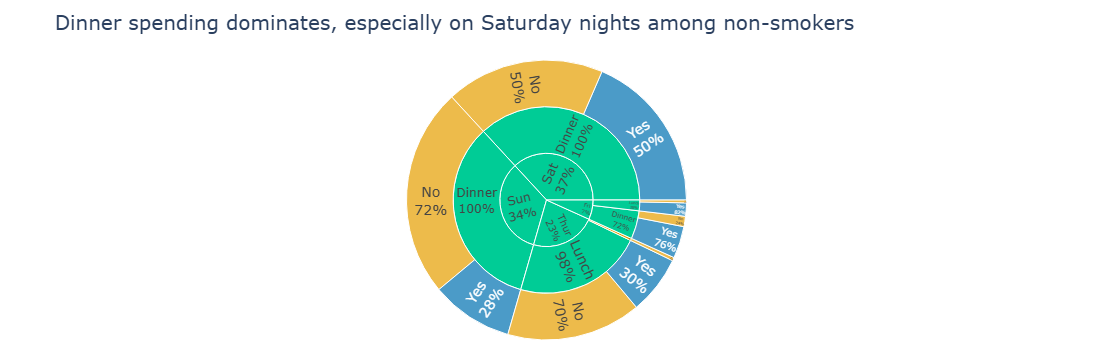

In [6]:
# Task 2
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# Load built-in tips dataset
tips = px.data.tips()

# Aggregate total bill sum by day, time, and smoker
tips_grouped = (
    tips.groupby(["day", "time", "smoker"])["total_bill"]
    .sum()
    .reset_index()
)

# Build sunburst chart
fig = px.sunburst(
    tips_grouped,
    path=["day", "time", "smoker"],
    values="total_bill",
    color="smoker",   # meaningful category
    color_discrete_map={
        "Yes": "#0072B2",   # blue
        "No": "#E69F00"     # orange
    },
    title="Dinner spending dominates, especially on Saturday nights among non-smokers"
)

# Customise labels and styling
fig.update_traces(
    textinfo="label+percent parent",
    insidetextorientation="radial",
    root_color="lightgrey"   # grey out parent/root nodes
)

fig.update_layout(
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=14)
)

fig.show()


Insight :Most spending happens during dinner rather than lunch.  
Saturday dinner contributes the highest total bill amount overall.  
Non-smokers account for a larger share of spending in most groups.  
This indicates dinner service drives the majority of restaurant revenue.

## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


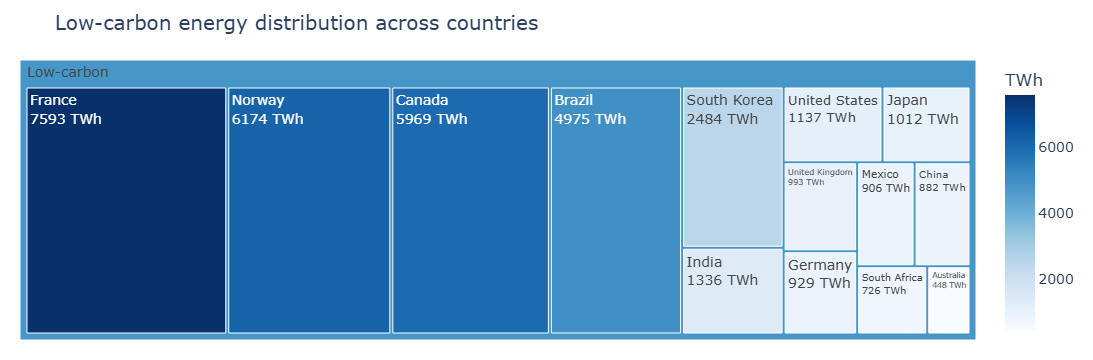

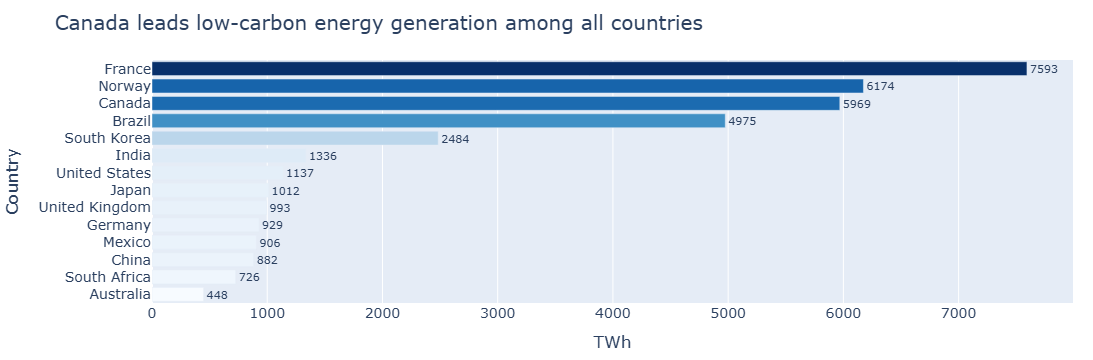

In [7]:
# Task 3 — charts
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("global_energy_mix.csv")

# Source type mapping
source_category = {
    'Coal': 'Fossil',
    'Oil': 'Fossil',
    'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon',
    'Hydro': 'Low-carbon',
    'Wind': 'Renewable',
    'Solar': 'Renewable',
    'Other Renewables': 'Renewable'
}

df["Source_Type"] = df["Source"].map(source_category)

# Filter low-carbon only
low_carbon = df.loc[df["Source_Type"] == "Low-carbon"]

# Aggregate TWh by country
low_carbon_country = (
    low_carbon.groupby("Country")["TWh"]
    .sum()
    .reset_index()
    .sort_values("TWh", ascending=False)
)

# Add dummy root for treemap
low_carbon_country["All"] = "Low-carbon"

# ---------------- TREEMAP ----------------
fig_tree = px.treemap(
    low_carbon_country,
    path=["All", "Country"],
    values="TWh",
    color="TWh",
    color_continuous_scale="Blues",
    title="Low-carbon energy distribution across countries"
)

fig_tree.update_traces(
    textinfo="label+value",
    texttemplate="%{label}<br>%{value} TWh",
    root_color="lightgrey"
)

fig_tree.update_layout(
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=14)
)

fig_tree.show()


# ---------------- BAR CHART ----------------
fig_bar = px.bar(
    low_carbon_country,
    x="TWh",
    y="Country",
    orientation="h",
    color="TWh",
    color_continuous_scale="Blues",
    text="TWh",
    title="Canada leads low-carbon energy generation among all countries"
)

fig_bar.update_traces(
    textposition="outside"
)

fig_bar.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=14),
    coloraxis_showscale=False
)

fig_bar.show()


# Treemap vs Bar Chart Comparison

The bar chart is clearer than the treemap for comparing low-carbon energy output across countries because bar lengths make it easier to compare exact TWh values.

The treemap is useful for showing part-to-whole relationships and overall distribution, but comparing similarly sized rectangles is harder than comparing bar lengths.

For this task, the horizontal bar chart is the better choice because the goal is to compare countries precisely and identify the leading producer.